In [34]:
import pandas as pd
df_dia2=pd.read_csv('diabetes (1).csv')
df_dia2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# EDA

In [35]:
df_dia2.shape

(768, 9)

In [36]:
df_dia2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [37]:
df_dia2.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


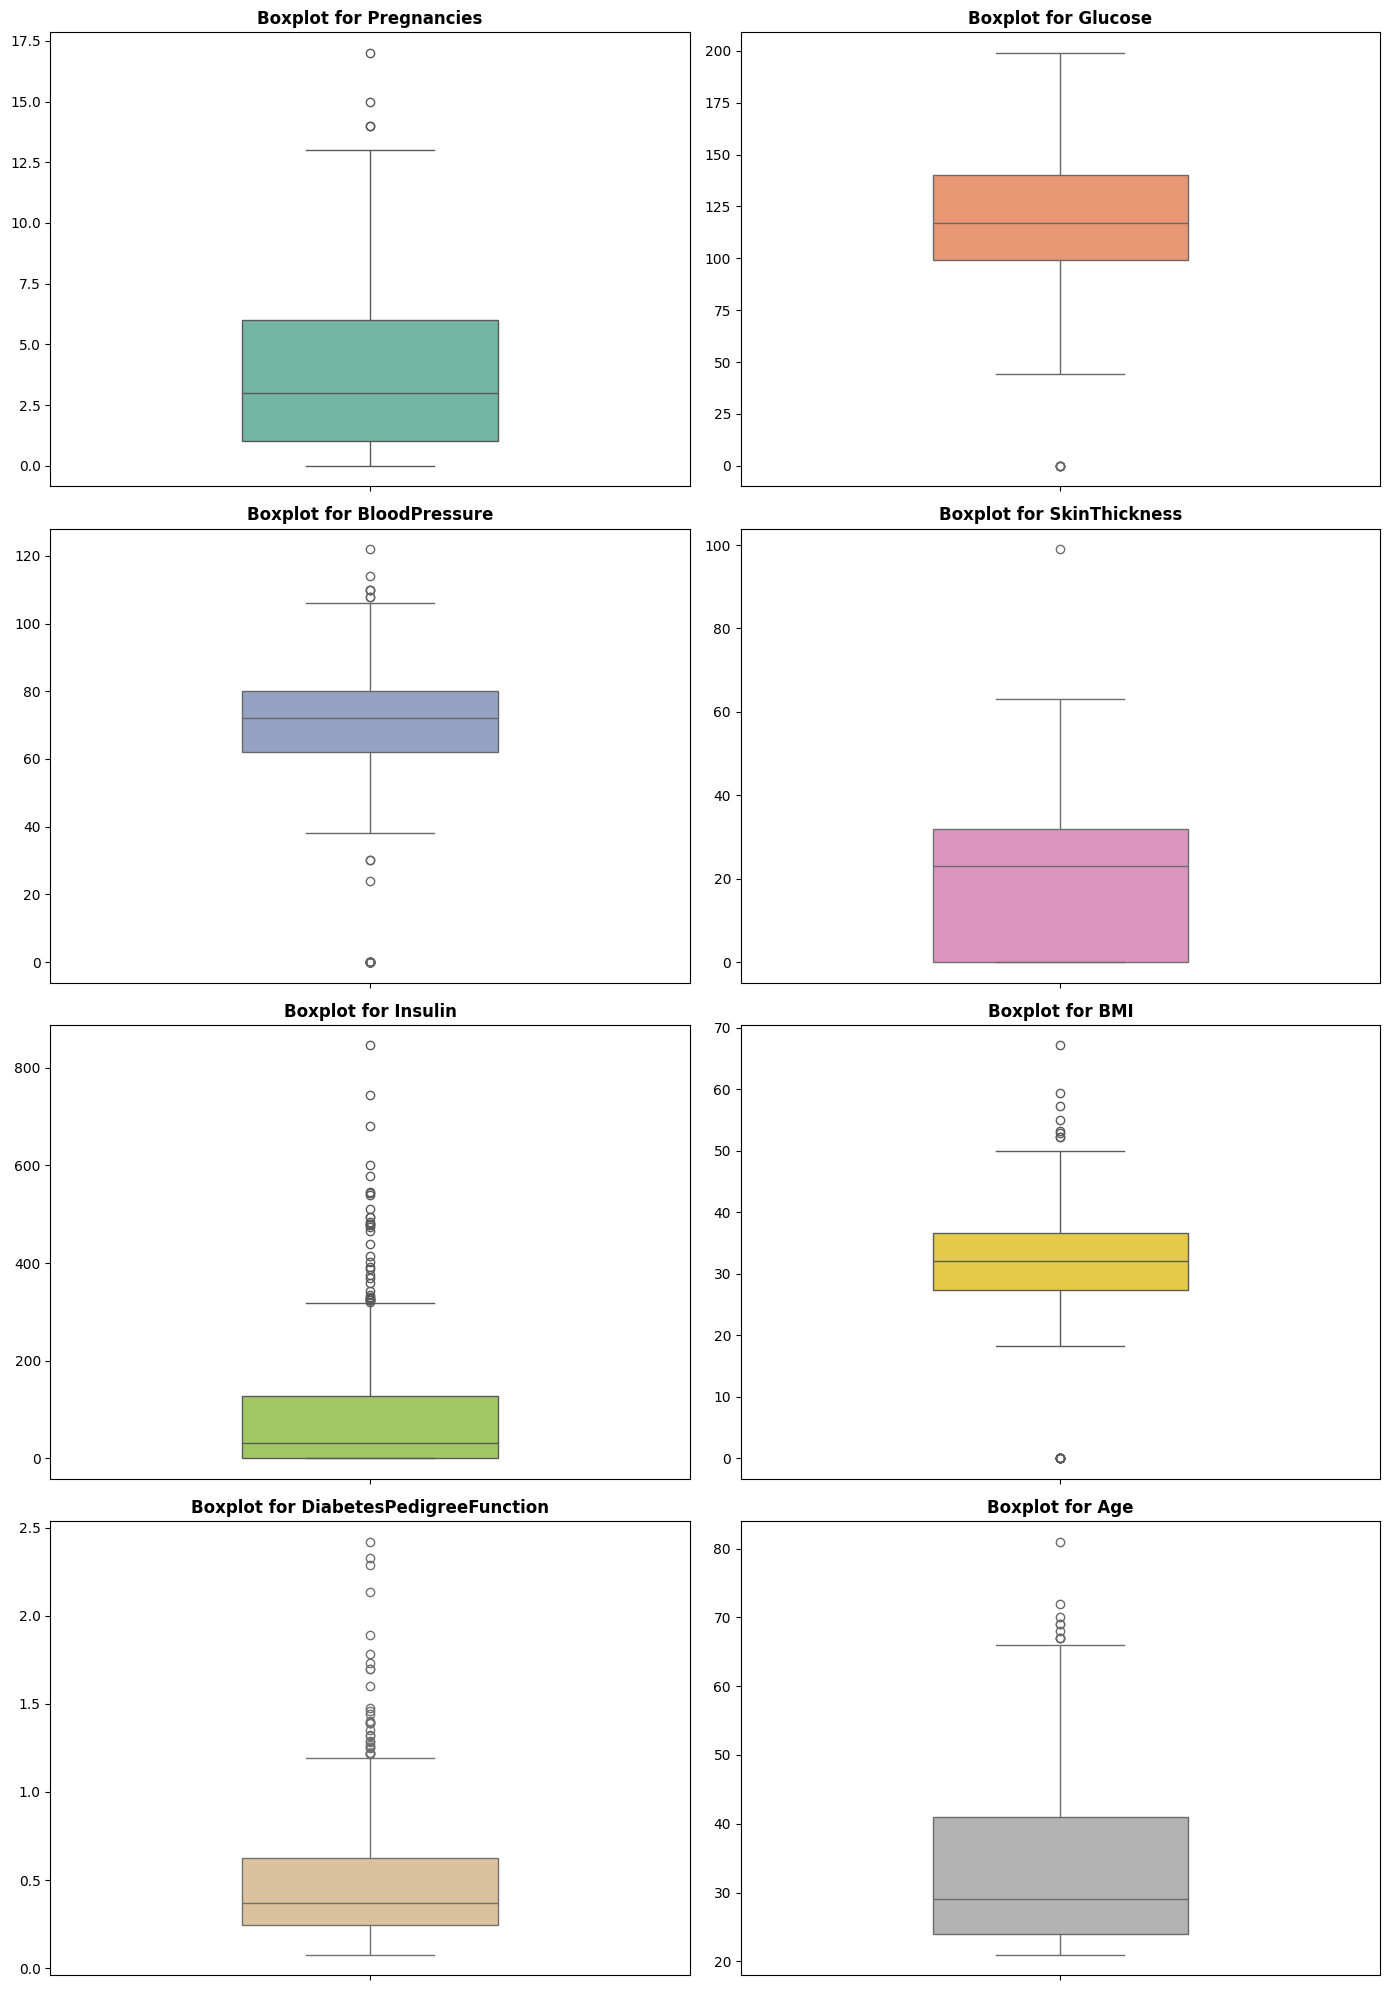

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_plot = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()     

colors = sns.color_palette("Set2", len(columns_to_plot))

for i, col in enumerate(columns_to_plot):
    sns.boxplot(y=df_dia2[col], ax=axes[i], color=colors[i], width=0.4)
    axes[i].set_title(f'Boxplot for {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') 
plt.tight_layout()
plt.savefig('my_data_boxplots.png', dpi=300)

# Handling missing value and outlayers

In [2]:
import numpy as np
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_dia2[cols_with_zeros] = df_dia2[cols_with_zeros].replace(0, np.nan)

In [3]:
df_dia2.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

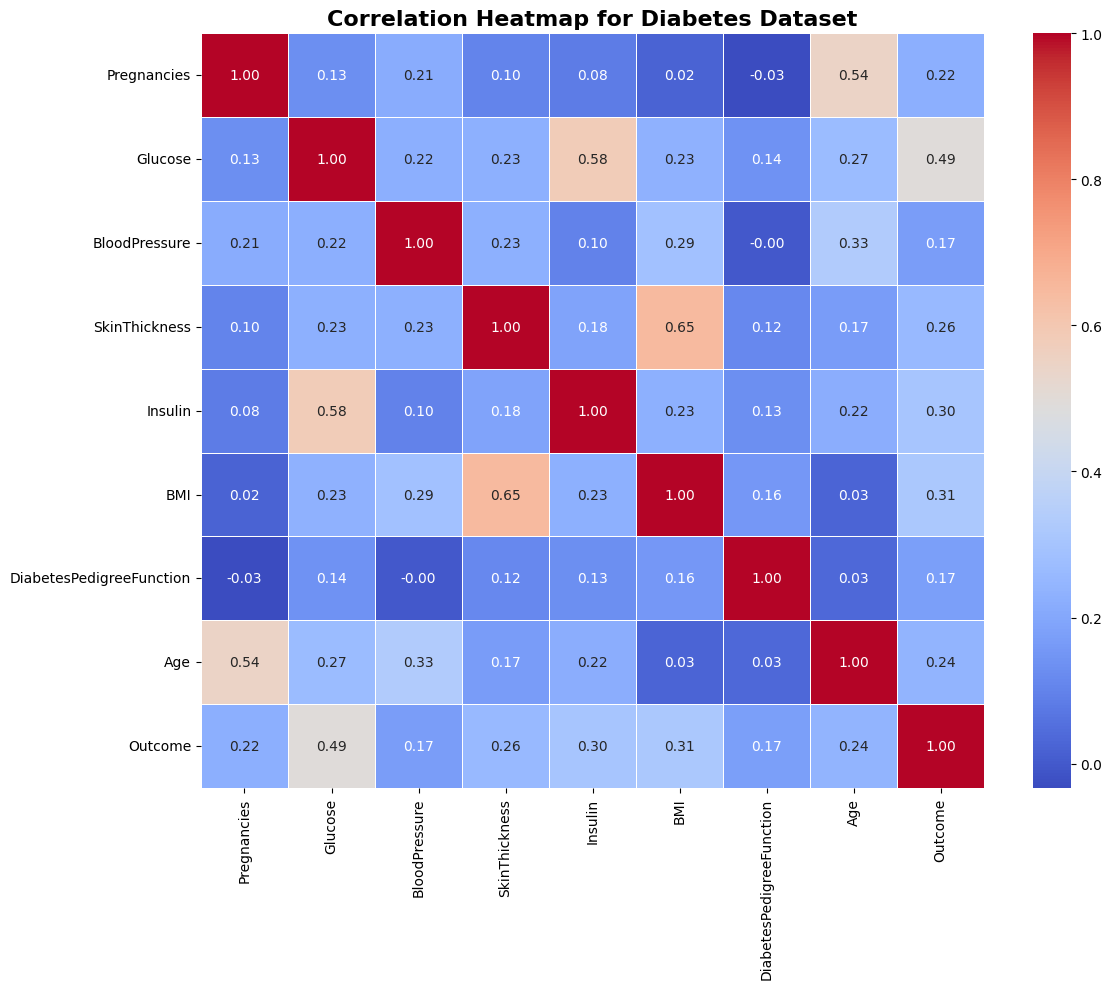

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_dia2.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Diabetes Dataset", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_dia2[df_dia2.columns] = imputer.fit_transform(df_dia2)

print(df_dia2.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


for col in numeric_cols:
    Q1 = df_dia2[col].quantile(0.25)
    Q3 = df_dia2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = df_dia2[(df_dia2[col] < lower_bound) | (df_dia2[col] > upper_bound)].shape[0]
    print(f"{col:<25} : {outliers_count} outlier")

Pregnancies               : 4 outlier
Glucose                   : 0 outlier
BloodPressure             : 14 outlier
SkinThickness             : 6 outlier
Insulin                   : 33 outlier
BMI                       : 8 outlier
DiabetesPedigreeFunction  : 29 outlier
Age                       : 9 outlier


In [9]:
Q1 = df_dia2['Pregnancies'].quantile(0.25)
Q3 = df_dia2['Pregnancies'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

pregnancies_outliers = df_dia2[df_dia2['Pregnancies'] > upper_bound]
pregnancies_outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
88,15.0,136.0,70.0,32.0,110.0,37.1,0.153,43.0,1.0
159,17.0,163.0,72.0,41.0,114.0,40.9,0.817,47.0,1.0
298,14.0,100.0,78.0,25.0,184.0,36.6,0.412,46.0,1.0
455,14.0,175.0,62.0,30.0,159.8,33.6,0.212,38.0,1.0


In [10]:
Q1 = df_dia2['BloodPressure'].quantile(0.25)
Q3 = df_dia2['BloodPressure'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

blood_pressure_outliers = df_dia2[(df_dia2['BloodPressure'] < lower_bound) | (df_dia2['BloodPressure'] > upper_bound)]
blood_pressure_outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
18,1.0,103.0,30.0,38.0,83.0,43.3,0.183,33.0,0.0
43,9.0,171.0,110.0,24.0,240.0,45.4,0.721,54.0,1.0
84,5.0,137.0,108.0,37.2,125.6,48.8,0.227,37.0,1.0
106,1.0,96.0,122.0,26.4,73.0,22.4,0.207,27.0,0.0
125,1.0,88.0,30.0,42.0,99.0,55.0,0.496,26.0,1.0
177,0.0,129.0,110.0,46.0,130.0,67.1,0.319,26.0,1.0
362,5.0,103.0,108.0,37.0,114.0,39.2,0.305,65.0,0.0
549,4.0,189.0,110.0,31.0,188.4,28.5,0.680,37.0,0.0
597,1.0,89.0,24.0,19.0,25.0,27.8,0.559,21.0,0.0
599,1.0,109.0,38.0,18.0,120.0,23.1,0.407,26.0,0.0


In [11]:
Q1 = df_dia2['SkinThickness'].quantile(0.25)
Q3 = df_dia2['SkinThickness'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

skin_thickness_outliers = df_dia2[(df_dia2['SkinThickness'] < lower_bound) | (df_dia2['SkinThickness'] > upper_bound)]
skin_thickness_outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
57,0.0,100.0,88.0,60.0,110.0,46.8,0.962,31.0,0.0
86,13.0,106.0,72.0,54.0,156.4,36.6,0.178,45.0,0.0
120,0.0,162.0,76.0,56.0,100.0,53.2,0.759,25.0,1.0
211,0.0,147.0,85.0,54.0,330.2,42.8,0.375,24.0,0.0
445,0.0,180.0,78.0,63.0,14.0,59.4,2.420,25.0,1.0
579,2.0,197.0,70.0,99.0,297.2,34.7,0.575,62.0,1.0


In [12]:
df_dia2.loc[df_dia2['SkinThickness'] == 99, 'SkinThickness'] = df_dia2['SkinThickness'].median()

In [13]:
Q1 = df_dia2['Insulin'].quantile(0.25)
Q3 = df_dia2['Insulin'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

insulin_outliers = df_dia2[(df_dia2['Insulin'] < lower_bound) | (df_dia2['Insulin'] > upper_bound)]
insulin_outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
8,2.0,197.0,70.0,45.0,543.0,30.5,0.158,53.0,1.0
13,1.0,189.0,60.0,23.0,846.0,30.1,0.398,59.0,1.0
45,0.0,180.0,66.0,39.0,370.4,42.0,1.893,25.0,1.0
111,8.0,155.0,62.0,26.0,495.0,34.0,0.543,46.0,1.0
153,1.0,153.0,82.0,42.0,485.0,40.6,0.687,23.0,0.0
185,7.0,194.0,68.0,28.0,350.6,35.9,0.745,41.0,1.0
186,8.0,181.0,68.0,36.0,495.0,30.1,0.615,60.0,1.0
220,0.0,177.0,60.0,29.0,478.0,34.6,1.072,21.0,1.0
228,4.0,197.0,70.0,39.0,744.0,36.7,2.329,31.0,0.0
231,6.0,134.0,80.0,37.0,370.0,46.2,0.238,46.0,1.0


In [14]:
Q1 = df_dia2['Age'].quantile(0.25)
Q3 = df_dia2['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

age_outliers = df_dia2[(df_dia2['Age'] < lower_bound) | (df_dia2['Age'] > upper_bound)]
age_outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
123,5.0,132.0,80.0,24.8,281.2,26.80,0.186,69.0,0.0
363,4.0,146.0,78.0,26.2,227.6,38.50,0.520,67.0,1.0
453,2.0,119.0,82.8,22.8,249.8,19.60,0.832,72.0,0.0
459,9.0,134.0,74.0,33.0,60.0,25.90,0.460,81.0,0.0
489,8.0,194.0,80.0,48.4,331.0,26.10,0.551,67.0,0.0
537,0.0,57.0,60.0,31.8,108.4,21.70,0.735,67.0,0.0
666,4.0,145.0,82.0,18.0,149.2,32.50,0.235,70.0,1.0
674,8.0,91.0,82.0,31.4,142.6,35.60,0.587,68.0,0.0
684,5.0,136.0,82.0,23.4,221.2,31.64,0.640,69.0,0.0


In [15]:
Q1 = df_dia2['BMI'].quantile(0.25)
Q3 = df_dia2['BMI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

bmi_outliers = df_dia2[(df_dia2['BMI'] < lower_bound) | (df_dia2['BMI'] > upper_bound)]
bmi_outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
120,0.0,162.0,76.0,56.0,100.0,53.2,0.759,25.0,1.0
125,1.0,88.0,30.0,42.0,99.0,55.0,0.496,26.0,1.0
177,0.0,129.0,110.0,46.0,130.0,67.1,0.319,26.0,1.0
193,11.0,135.0,84.8,35.2,190.6,52.3,0.578,40.0,1.0
247,0.0,165.0,90.0,33.0,680.0,52.3,0.427,23.0,0.0
303,5.0,115.0,98.0,42.6,216.0,52.9,0.209,28.0,1.0
445,0.0,180.0,78.0,63.0,14.0,59.4,2.420,25.0,1.0
673,3.0,123.0,100.0,35.0,240.0,57.3,0.880,22.0,0.0


In [16]:
Q1 = df_dia2['DiabetesPedigreeFunction'].quantile(0.25)
Q3 = df_dia2['DiabetesPedigreeFunction'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

pedigree_outliers = df_dia2[(df_dia2['DiabetesPedigreeFunction'] < lower_bound) | (df_dia2['DiabetesPedigreeFunction'] > upper_bound)]
pedigree_outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0.0,137.0,40.0,35.0,168.0,43.10,2.288,33.0,1.0
12,10.0,139.0,80.0,22.6,204.0,27.10,1.441,57.0,0.0
39,4.0,111.0,72.0,47.0,207.0,37.10,1.390,56.0,1.0
45,0.0,180.0,66.0,39.0,370.4,42.00,1.893,25.0,1.0
58,0.0,146.0,82.0,40.8,197.0,40.50,1.781,44.0,0.0
100,1.0,163.0,72.0,31.2,248.6,39.00,1.222,33.0,1.0
147,2.0,106.0,64.0,35.0,119.0,30.50,1.400,34.0,0.0
187,1.0,128.0,98.0,41.0,58.0,32.00,1.321,33.0,1.0
218,5.0,85.0,74.0,22.0,59.0,29.00,1.224,32.0,1.0
228,4.0,197.0,70.0,39.0,744.0,36.70,2.329,31.0,0.0


# Feature engineering

In [20]:
df_dia2['Fat_Mass_Proxy'] = df_dia2['BMI'] * df_dia2['SkinThickness']
df_dia2['Glucose_Insulin_Ratio'] = df_dia2['Glucose'] / (df_dia2['Insulin'] + 1e-5)
df_dia2['Pregnancies_per_Age'] = df_dia2['Pregnancies'] / df_dia2['Age']
df_dia2['BP_Age_Product'] = df_dia2['BloodPressure'] * df_dia2['Age']

Fat_Mass_Proxy           0.304042
BP_Age_Product           0.251629
Pregnancies_per_Age      0.163744
Glucose_Insulin_Ratio   -0.135318
Name: Outcome, dtype: float64


C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_22836\582943821.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=new_corr.values, y=new_corr.index, palette="coolwarm")


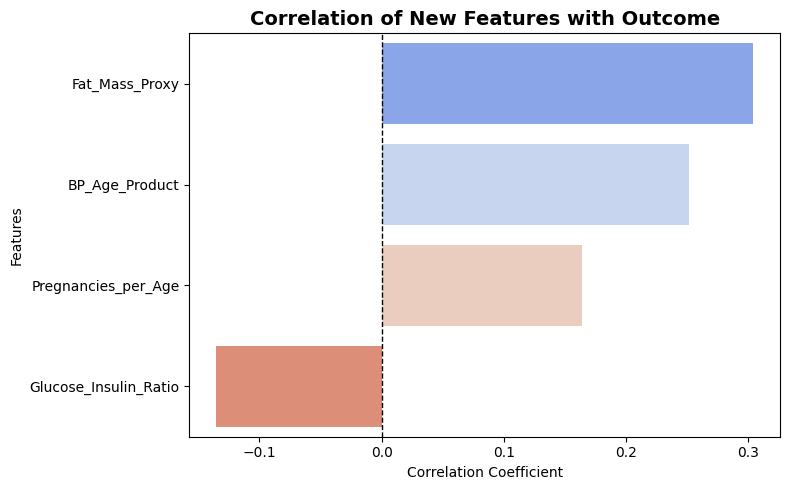

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_dia2.corr()

new_features = ['Fat_Mass_Proxy', 'Glucose_Insulin_Ratio', 'Pregnancies_per_Age', 'BP_Age_Product']
new_corr = corr_matrix.loc[new_features, 'Outcome'].sort_values(ascending=False)

print(new_corr)

plt.figure(figsize=(8, 5))
sns.barplot(x=new_corr.values, y=new_corr.index, palette="coolwarm")
plt.title("Correlation of New Features with Outcome", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # خط الصفر للفصل
plt.tight_layout()
plt.show()

# Building best model

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = df_dia2.drop(columns=['Outcome'])
y = df_dia2['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='linear', random_state=42,class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

print("SVM (on KNN Data) Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

SVM (on KNN Data) Accuracy Score: 0.7402597402597403

Confusion Matrix:
 [[75 25]
 [15 39]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.75      0.79       100
         1.0       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_final = df_dia2.drop(columns=['Outcome'])
y_final = df_dia2['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

print("Final Gradient Boosting Accuracy Score (All Features):", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Gradient Boosting Accuracy Score (All Features): 0.7402597402597403

Confusion Matrix:
 [[83 17]
 [23 31]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.78      0.83      0.81       100
         1.0       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



Metric             Accuracy  Precision (Class 1)  Recall (Class 1)
Model                                                             
Gradient Boosting   0.74026             0.645833          0.574074
SVM                 0.74026             0.609375          0.722222


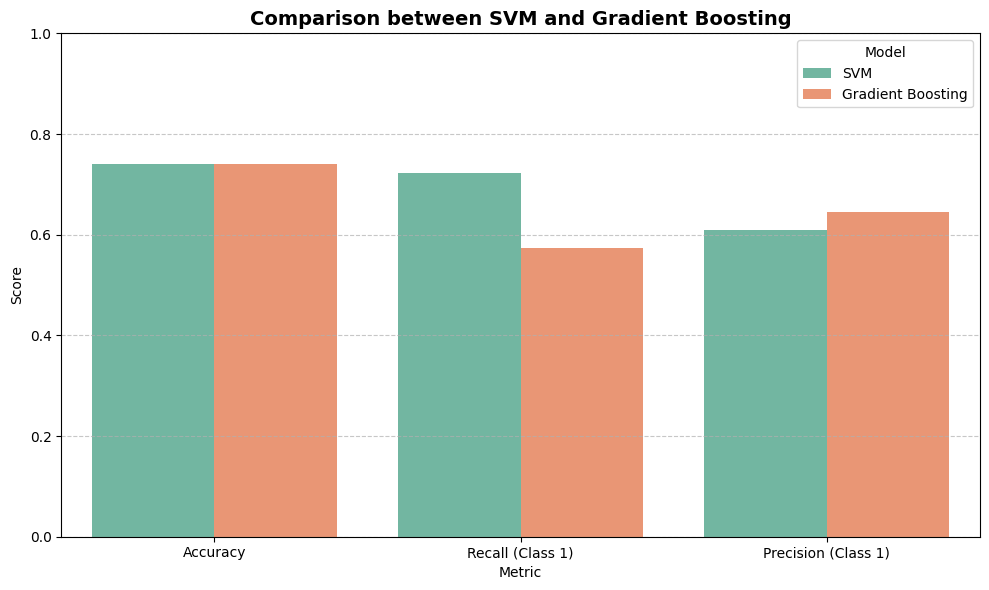

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score

svm_pred = svm_model.predict(X_test_scaled)
gb_pred = gb_model.predict(X_test)

results = {
    'Model': ['SVM', 'SVM', 'SVM', 'Gradient Boosting', 'Gradient Boosting', 'Gradient Boosting'],
    'Metric': ['Accuracy', 'Recall (Class 1)', 'Precision (Class 1)', 'Accuracy', 'Recall (Class 1)', 'Precision (Class 1)'],
    'Value': [
        accuracy_score(y_test, svm_pred),
        recall_score(y_test, svm_pred),
        precision_score(y_test, svm_pred),
        accuracy_score(y_test, gb_pred),
        recall_score(y_test, gb_pred),
        precision_score(y_test, gb_pred)
    ]
}

df_results = pd.DataFrame(results)

print(df_results.pivot(index='Model', columns='Metric', values='Value'))

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Metric', y='Value', hue='Model', palette='Set2')
plt.title('Comparison between SVM and Gradient Boosting', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

In [31]:
patient_diabetic = {
    'Pregnancies': 5,
    'Glucose': 166.0,
    'BloodPressure': 72.0,
    'SkinThickness': 19.0,
    'Insulin': 175.0,
    'BMI': 25.8,
    'DiabetesPedigreeFunction': 0.587,
    'Age': 51,
    'Fat_Mass_Proxy': 25.8 * 19.0,
    'Glucose_Insulin_Ratio': 166.0 / (175.0 + 1e-5),
    'Pregnancies_per_Age': 5 / 51,
    'BP_Age_Product': 72.0 * 51
}

In [32]:
import pandas as pd

patient_to_test = patient_diabetic

df_test = pd.DataFrame([patient_to_test])
df_test_scaled = scaler.transform(df_test)
prediction = svm_model.predict(df_test_scaled)

if prediction[0] == 1:
    print("(Class 1)")
else:
    print("(Class 0)")

(Class 1)
